In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip -q install nnunetv2 nibabel medpy SimpleITK


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 kB 9.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 92.4 

In [ ]:
# EDIT ONLY if your Drive layout differs
RESULTS_DIR = "/content/drive/MyDrive/Brain_segmentation"                      # contains Dataset002_BRATS19/...
CASE_DIR    = "/content/drive/MyDrive/Brain_segmentation/Sample_data/BraTS-MET-00086-000"

import os, subprocess
os.environ["nnUNet_results"] = RESULTS_DIR
print("nnUNet_results =", os.environ["nnUNet_results"])

# Sanity checks
subprocess.run(["ls","-la",RESULTS_DIR])
subprocess.run(["ls","-la",CASE_DIR])


nnUNet_results = /content/drive/MyDrive/Brain_segmentation


CompletedProcess(args=['ls', '-la', '/content/drive/MyDrive/Brain_segmentation/Sample_data/BraTS-MET-00086-000'], returncode=0)

In [ ]:
from pathlib import Path
import nibabel as nib, shutil

src = Path(CASE_DIR)
dst = Path("/content/nnunet_in"); dst.mkdir(parents=True, exist_ok=True)
gt_out = Path("/content/gt"); gt_out.mkdir(parents=True, exist_ok=True)

case = "BraTS-MET-00086-000"

# Source files (your exact names are .nii)
t1    = src/f"{case}-t1n.nii"
t1ce  = src/f"{case}-t1c.nii"
t2    = src/f"{case}-t2w.nii"
flair = src/f"{case}-t2f.nii"
seg   = src/f"{case}-seg.nii"     # GT (optional but used for eval)

# Write in nnU-Net order: 0=t1, 1=t1ce, 2=t2, 3=flair
nib.save(nib.load(str(t1)),    str(dst/f"{case}_0000.nii.gz"))
nib.save(nib.load(str(t1ce)),  str(dst/f"{case}_0001.nii.gz"))
nib.save(nib.load(str(t2)),    str(dst/f"{case}_0002.nii.gz"))
nib.save(nib.load(str(flair)), str(dst/f"{case}_0003.nii.gz"))

# Copy GT for evaluation (if present)
if seg.exists():
    nib.save(nib.load(str(seg)), str(gt_out/f"{case}.nii.gz"))

print("Prepared inputs:", sorted([p.name for p in dst.glob("*.nii.gz")]))


Prepared inputs: ['BraTS-MET-00086-000_0000.nii.gz', 'BraTS-MET-00086-000_0001.nii.gz', 'BraTS-MET-00086-000_0002.nii.gz', 'BraTS-MET-00086-000_0003.nii.gz']


In [ ]:
# QUICK sanity (single fold 0)
!nnUNetv2_predict \
  -i /content/nnunet_in \
  -o /content/preds_met \
  -d Dataset002_BRATS19 \
  -c 3d_fullres \
  -tr nnUNetTrainer \
  -p nnUNetPlans \
  -f 0

# TIP for best accuracy later:
# nnUNetv2_predict -i /content/nnunet_in -o /content/preds_met -d Dataset002_BRATS19 -c 3d_fullres -tr nnUNetTrainer -p nnUNetPlans -f 0 1 2 3 4


nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

/usr/local/lib/python3.12/dist-packages/nnunetv2/utilities/plans_handl

In [ ]:
import numpy as np, nibabel as nib, os
from medpy.metric.binary import dc

pred_path = f"/content/preds_met/{case}.nii.gz"
gt_path   = f"/content/gt/{case}.nii.gz"

pred = nib.load(pred_path).get_fdata().astype(np.int16)
print("Unique pred labels:", np.unique(pred))

if os.path.exists(gt_path):
    gt = nib.load(gt_path).get_fdata().astype(np.int16)
    print("Whole-tumor Dice:", float(dc(pred>0, gt>0)))

    # BraTS labels: 1=edema, 2=nonenh/necrotic, 4=enhancing
    per = {l: (float(dc(pred==l, gt==l)) if (gt==l).any() or (pred==l).any() else np.nan) for l in [1,2,4]}
    print("Per-class Dice:", per)
else:
    print("No GT found; skipping Dice evaluation.")


Unique pred labels: [0 1 2 4]
Whole-tumor Dice: 0.4933402525514617
Per-class Dice: {1: 0.0, 2: 0.4725497420781135, 4: 0.0}


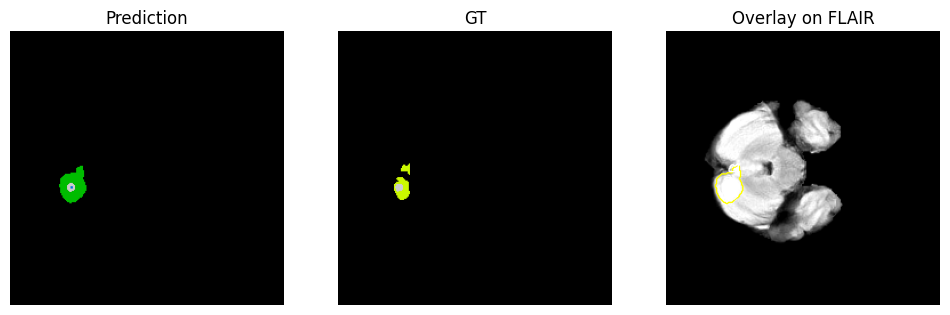

In [ ]:
import matplotlib.pyplot as plt

flair_img = nib.load(f"/content/nnunet_in/{case}_0003.nii.gz").get_fdata()  # FLAIR as background
z = int(np.median(np.where(pred>0)[2])) if (pred>0).any() else pred.shape[2]//2
p1,p99 = np.percentile(flair_img,[1,99]); bg = np.clip((flair_img-p1)/max(p99-p1,1e-6),0,1)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Prediction"); plt.imshow(pred[:,:,z], cmap='nipy_spectral'); plt.axis('off')
if os.path.exists(gt_path):
    gt = nib.load(gt_path).get_fdata().astype(np.int16)
    plt.subplot(1,3,2); plt.title("GT"); plt.imshow(gt[:,:,z], cmap='nipy_spectral'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Overlay on FLAIR")
plt.imshow(bg[:,:,z], cmap='gray')
plt.contour(pred[:,:,z]>0, colors='yellow', linewidths=1)
if os.path.exists(gt_path): plt.contour(gt[:,:,z]>0, colors='white', linewidths=1)
plt.axis('off'); plt.show()


In [ ]:
import os

def print_tree(startpath, prefix=""):
    """Recursively print a tree view of directories and files."""
    items = sorted(os.listdir(startpath))
    for idx, name in enumerate(items):
        path = os.path.join(startpath, name)
        connector = "└── " if idx == len(items) - 1 else "├── "
        print(prefix + connector + name)
        if os.path.isdir(path):
            extension = "    " if idx == len(items) - 1 else "│   "
            print_tree(path, prefix + extension)

root_dir = "/content/drive/MyDrive/Brain_segmentation"

print(f"📂 Folder tree for: {root_dir}\n")
print_tree(root_dir)


📂 Folder tree for: /content/drive/MyDrive/Brain_segmentation

├── Brain_MRI_segmentation.ipynb
├── Copy of Brain_MRI_segmentation.ipynb
├── Dataset002_BRATS19
│   └── nnUNetTrainer__nnUNetPlans__3d_fullres
│       ├── dataset.json
│       ├── dataset_fingerprint.json
│       ├── fold_0
│       │   ├── checkpoint_final.pth
│       │   ├── network_architecture.pdf
│       │   └── progress.png
│       ├── fold_1
│       │   ├── checkpoint_final.pth
│       │   └── progress.png
│       ├── fold_2
│       │   ├── checkpoint_final.pth
│       │   └── progress.png
│       ├── fold_3
│       │   ├── checkpoint_final.pth
│       │   └── progress.png
│       ├── fold_4
│       │   ├── checkpoint_final.pth
│       │   └── progress.png
│       └── plans.json
└── Sample_data
    ├── BaTS_2021
    │   ├── .DS_Store
    │   ├── BraTS2021_00495
    │   │   ├── .DS_Store
    │   │   ├── BraTS2021_00495_flair.nii
    │   │   ├── BraTS2021_00495_seg.nii
    │   │   ├── BraTS2021_00495_t1.nii
    │   │   